In [2]:
# !pip install sounddevice

In [4]:
# Task 1: Record your voice by saying "Hello" and save it as .wav file. 
# Read it and display the voice.

In [23]:
import sounddevice as sd
import numpy as np
from scipy.io.wavfile import read,write
import matplotlib.pyplot as plt

In [24]:
fs = 44100
dur = 3
rec = sd.rec(int(fs*dur), samplerate=fs, channels=2)
sd.wait()

In [25]:
write('/home/karthikmsd/sem9/20XW97-CV-LAB/ws1/myrec.wav', fs, rec)

In [26]:
s_rate, audio_array = read('/home/karthikmsd/sem9/20XW97-CV-LAB/ws1/myrec.wav')

In [27]:
audio_array.shape

(132300, 2)

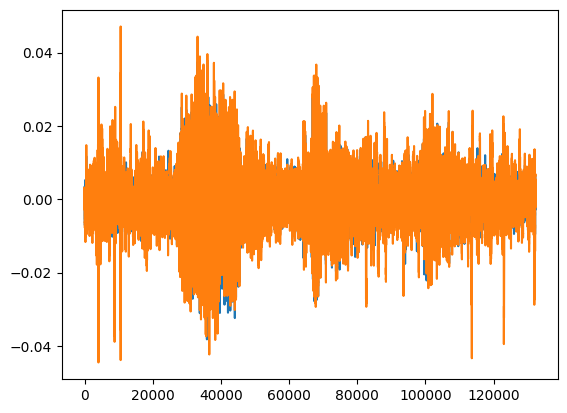

In [60]:
plt.plot(audio_array)

In [61]:
import cv2
import random

In [62]:
img = cv2.imread('/home/karthikmsd/sem9/20XW97-CV-LAB/assets/images/cameraman.tif', 0)

In [64]:
imlist = []

for npa in img:
    arr = list(npa)
    random.shuffle(arr)    
    imlist.append(arr)
random.shuffle(imlist)

In [65]:
scrambled = np.zeros([len(imlist), len(imlist[0])])

In [66]:
for i in range(len(imlist)):
    for j in range(len(imlist[0])):
        scrambled[i, j] = imlist[i][j]

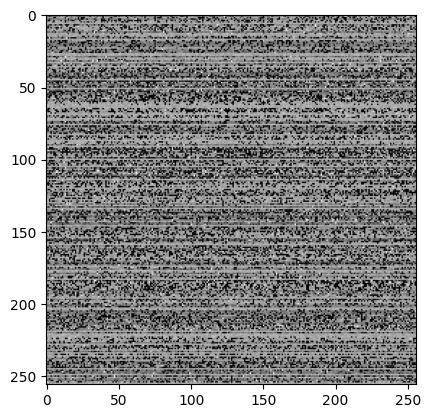

In [67]:
plt.imshow(scrambled, cmap='gray')

In [68]:
# LLOYD max quantization

In [127]:
img = cv2.imread('/home/karthikmsd/sem9/20XW97-CV-LAB/assets/images/cameraman.tif', 0)

In [128]:
m, n = img.shape

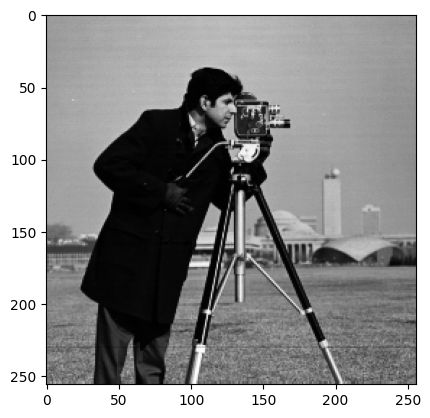

In [129]:
plt.imshow(img, cmap='gray')

In [149]:
def LMAX_quant(img):
    epochs = 1
    q_levels = []

    Ti = []
    vmin = 0
    vmax = 255
    n = 10 # intervals for lmax quant

    for i in range(1, n+1):
        Ti.append(vmin+((i-0.5)/n)*(vmax-vmin))
    # while True:
    #     Ti = []
    #     vmin = 0
    #     vmax = 255
    #     n = 6 # intervals for lmax quant
    
    #     for i in range(1, n+1):
    #         Ti.append(vmin+((i-0.5)/n)*(vmax-vmin))
    
    #     # print(Ti)
    
    #     Si = []
    
    #     for i in range(n-1):
    #         Si.append((Ti[i]+Ti[i+1])*0.5)

    #     Si.insert(0, 0)
    #     Si.append(255)
    #     # print(Si)
        
    #     NewTi = []
    
    #     for i in range(1, n+1):
    #         NewTi.append((Si[i-1]+Si[i])*0.5)

    #     # print(NewTi)

    #     if all([Ti[i]==NewTi[i] for i in range(n)]):
    #         q_levels = Ti[:]
    #         print(f'Interval converged at epoch{epochs}')
    #         break
    #     epochs += 1
    q_levels = Ti[:]
    return q_levels

In [150]:
q_levels = LMAX_quant(img)

In [151]:
q_img = np.zeros([m, n])
s = [0] + [(q_levels[i]+q_levels[i+1])*0.5 for i in range(len(q_levels)-1)] + [255]

for i in range(m):
    for j in range(n):
        pix  = img[i][j]

        for k in range(len(s)-1):
            l1, l2 = s[k], s[k+1]
            if l1<=pix<=l2:
                q_img[i][j] = q_levels[k]

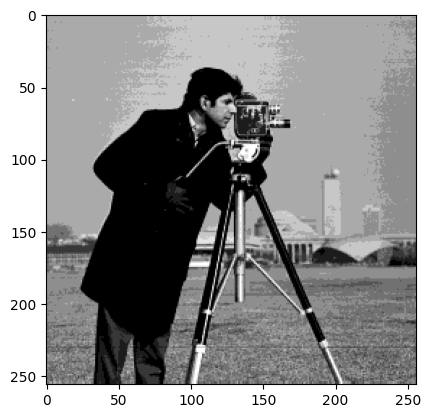

In [152]:
plt.imshow(q_img, cmap='gray')

In [159]:
# 3. img file format
import os

In [155]:
img = cv2.imread('/home/karthikmsd/sem9/20XW97-CV-LAB/assets/images/cameraman.tif', 0)

In [157]:
cv2.imwrite('cameraman.png' , img)
cv2.imwrite('cameraman.jpg', img)

True

In [158]:
size = {}

In [160]:
size['tif'] = os.path.getsize('/home/karthikmsd/sem9/20XW97-CV-LAB/assets/images/cameraman.tif')
size['jpg'] = os.path.getsize('cameraman.jpg')
size['png'] = os.path.getsize('cameraman.png')

<BarContainer object of 3 artists>

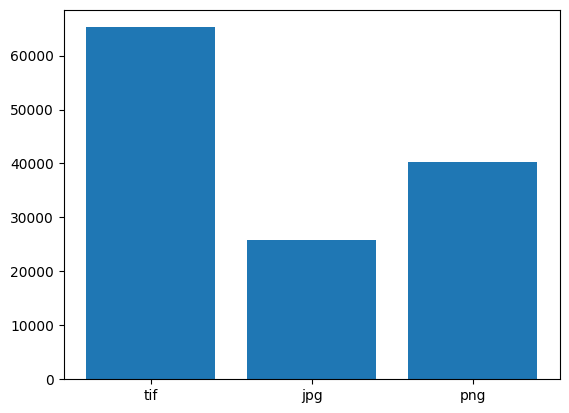

In [161]:
plt.bar(size.keys(), size.values())